# Amazon Product Review NLP Analysis
### Data Preprocessing & Exploratory Data Analysis

## Project Overview

This notebook focuses on preprocessing and exploratory data analysis (EDA) for Amazon product review data. The objective is to clean customer review text, handle missing values, and to engineer NLP-ready features. Also analyze customer sentiment trends across products and categories.

The preprocessing pipeline prepares review text for downstream machine learning and deep learning models used later in the capstone project.

# **Load + Explore Dataset**

In [17]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from bs4 import BeautifulSoup

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Dataset Overview

The dataset contains structured and unstructured ecommerce review data. That is including the product information, customer ratings, and review data. I'd also like to mention it includes the  pricing data and product categories.

Key NLP-related fields include:
- review_content
- review_title
- rating
- category
- product_name

In [19]:
df = pd.read_csv("amazon.csv")

print(df.shape)

display(df.head())

(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


# **Missing Value Handling & Text Cleaning**

In [20]:
# Using English stopwords to remove filler/common words
# so the NLP models focus more on meaningful review language
STOP = set(stopwords.words("english"))

# Lemmatizer helps normalize words into root/base forms
# Example: "running" -> "run"
lemmatizer = WordNetLemmatizer()


def to_float_rating(series):

    # Converts ratings safely into numeric format
    # Any broken values automatically become NaN
    return pd.to_numeric(series, errors="coerce")


def to_float_discount(series):

    # Cleans percentage formatting before numeric conversion
    # Example: "45%" -> 45
    s = series.astype(str).str.strip()

    s = s.str.rstrip("%").str.strip()

    return pd.to_numeric(s, errors="coerce")


def clean_missing_review_text(series):

    # Standardizing blank/missing review text values
    # so NLP processing doesn’t break later
    s = series.astype(str).str.strip()

    s = s.replace({
        "": np.nan,
        "nan": np.nan,
        "None": np.nan
    })

    return s


# Converting ratings into clean numeric values first
df["rating"] = to_float_rating(df["rating"])

# Using median because it’s more robust against outliers
median_rating = df["rating"].median()

# Filling missing ratings
df["rating"] = df["rating"].fillna(median_rating)


# Cleaning discount percentage column
df["discount_percentage"] = to_float_discount(
    df["discount_percentage"]
)

# Median fill again for stability
median_discount = df["discount_percentage"].median()

df["discount_percentage"] = df[
    "discount_percentage"
].fillna(median_discount)


# Cleaning review text column
df["review_content"] = clean_missing_review_text(
    df["review_content"]
)

# Keeping placeholder text instead of dropping rows
# so row counts stay consistent across the pipeline
df["review_content"] = df[
    "review_content"
].fillna("[no review text]")


def strip_html(text):

    # Removes HTML tags from scraped review content
    return BeautifulSoup(
        text,
        "html.parser"
    ).get_text(separator=" ")


def remove_urls(text):

    # Removes web links because URLs create noisy tokens
    return re.sub(
        r"http\S+|www\S+",
        "",
        text
    )


def remove_special_chars(text):

    # Removes punctuation/symbols while preserving letters/numbers
    return re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )


def preprocess_review(text):

    # Basic safety check
    if not isinstance(text, str):
        return ""

    # Removing HTML first before tokenization
    t = strip_html(text)

    # Removing URLs next to reduce vocabulary noise
    t = remove_urls(t)

    # Lowercasing + removing special characters
    # so words normalize consistently
    t = remove_special_chars(t).lower()

    # Splitting text into individual tokens
    tokens = word_tokenize(t)

    # Keeping only meaningful alphabetic words
    # Removes tiny junk tokens/noise
    tokens = [
        w for w in tokens
        if w.isalpha() and len(w) > 1
    ]

    # Removing stopwords to improve NLP signal quality
    tokens = [
        w for w in tokens
        if w not in STOP
    ]

    # Lemmatizing tokens into root forms
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
    ]

    # Rejoining cleaned tokens into final cleaned review text
    return " ".join(tokens)


def preprocess_review_tokens(text):

    # Token version useful later for advanced NLP/debugging
    s = preprocess_review(text)

    return s.split() if s else []


# Creating cleaned review text column
df["review_clean"] = df[
    "review_content"
].map(preprocess_review)

# Creating tokenized review column
df["review_tokens"] = df[
    "review_content"
].map(preprocess_review_tokens)


# Final validation to ensure no missing values remain
print(
    df[
        [
            "review_content",
            "rating",
            "discount_percentage"
        ]
    ].isna().sum()
)

# Comparing original review text vs cleaned review text
display(
    df[
        [
            "review_content",
            "review_clean"
        ]
    ].head(5)
)

review_content         0
rating                 0
discount_percentage    0
dtype: int64


,review_content,review_clean
0,Looks durable Charging is fine tooNo complains...,look durable charging fine toono complains cha...
1,I ordered this cable to connect my phone to An...,ordered cable connect phone android auto car c...
2,"Not quite durable and sturdy,https://m.media-a...",quite durable sturdy good nice product working...
3,"Good product,long wire,Charges good,Nice,I bou...",good product long wire charge good nice bought...
4,"Bought this instead of original apple, does th...",bought instead original apple work fast apple ...


# **Most & Least Reviewed Products**

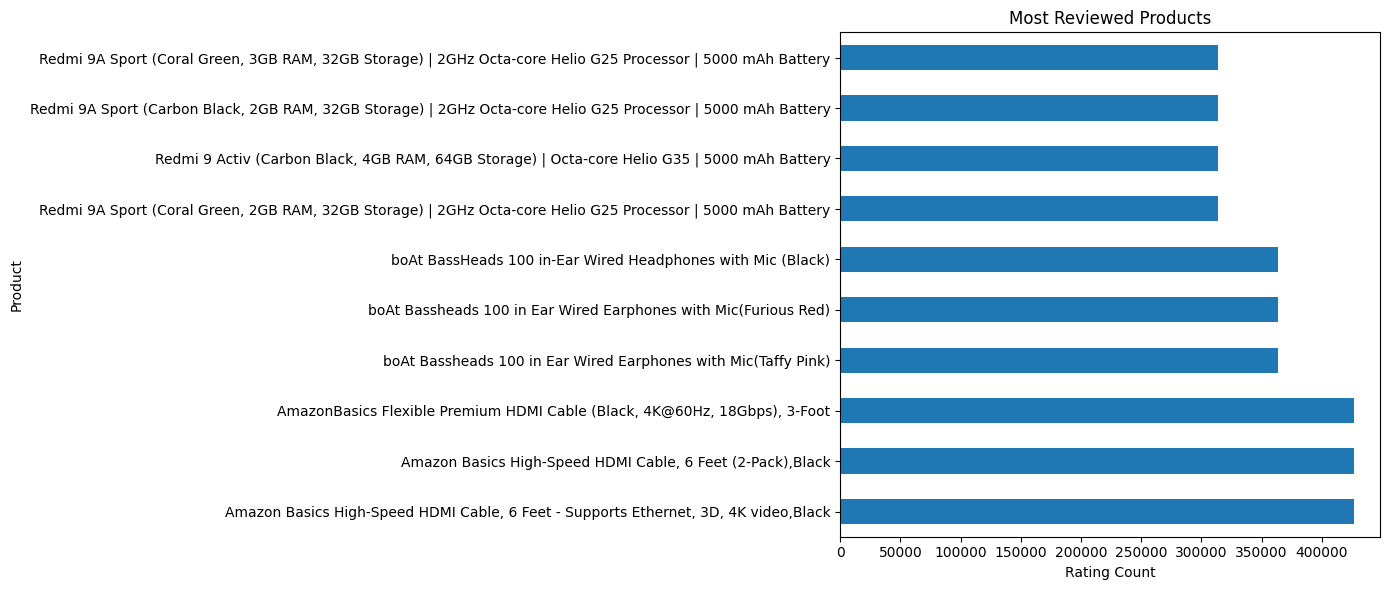

In [28]:
plt.figure(figsize=(14,6))

top_products.plot(
    kind="barh"
)

plt.title("Most Reviewed Products")

plt.xlabel("Rating Count")

plt.ylabel("Product")

plt.tight_layout()

plt.show()


/tmp/ipykernel_4036/2297900826.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


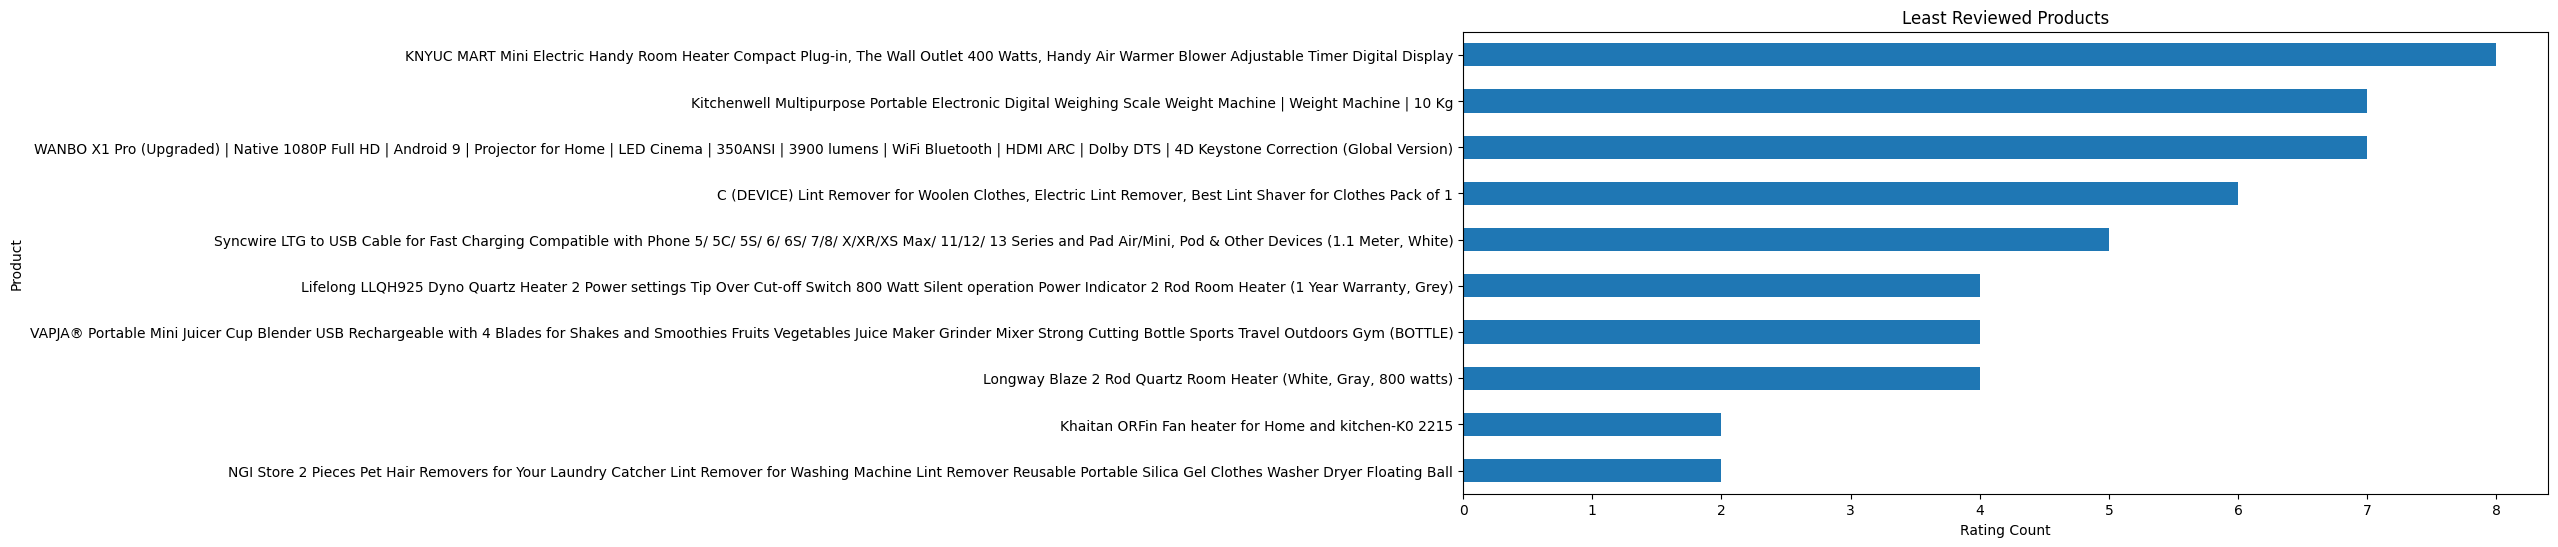

In [27]:
plt.figure(figsize=(14,6))

least_products.plot(
    kind="barh"
)

plt.title("Least Reviewed Products")

plt.xlabel("Rating Count")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [29]:
summary_stats = df[
    [
        "rating",
        "discount_percentage",
        "actual_price",
        "discounted_price"
    ]
].describe()

display(summary_stats)


,rating,discount_percentage
count,1465.000000,1465.000000
mean,4.096587,47.691468
std,0.291574,21.635905
min,2.000000,0.000000
25%,4.000000,32.000000
50%,4.100000,50.000000
75%,4.300000,63.000000
max,5.000000,94.000000


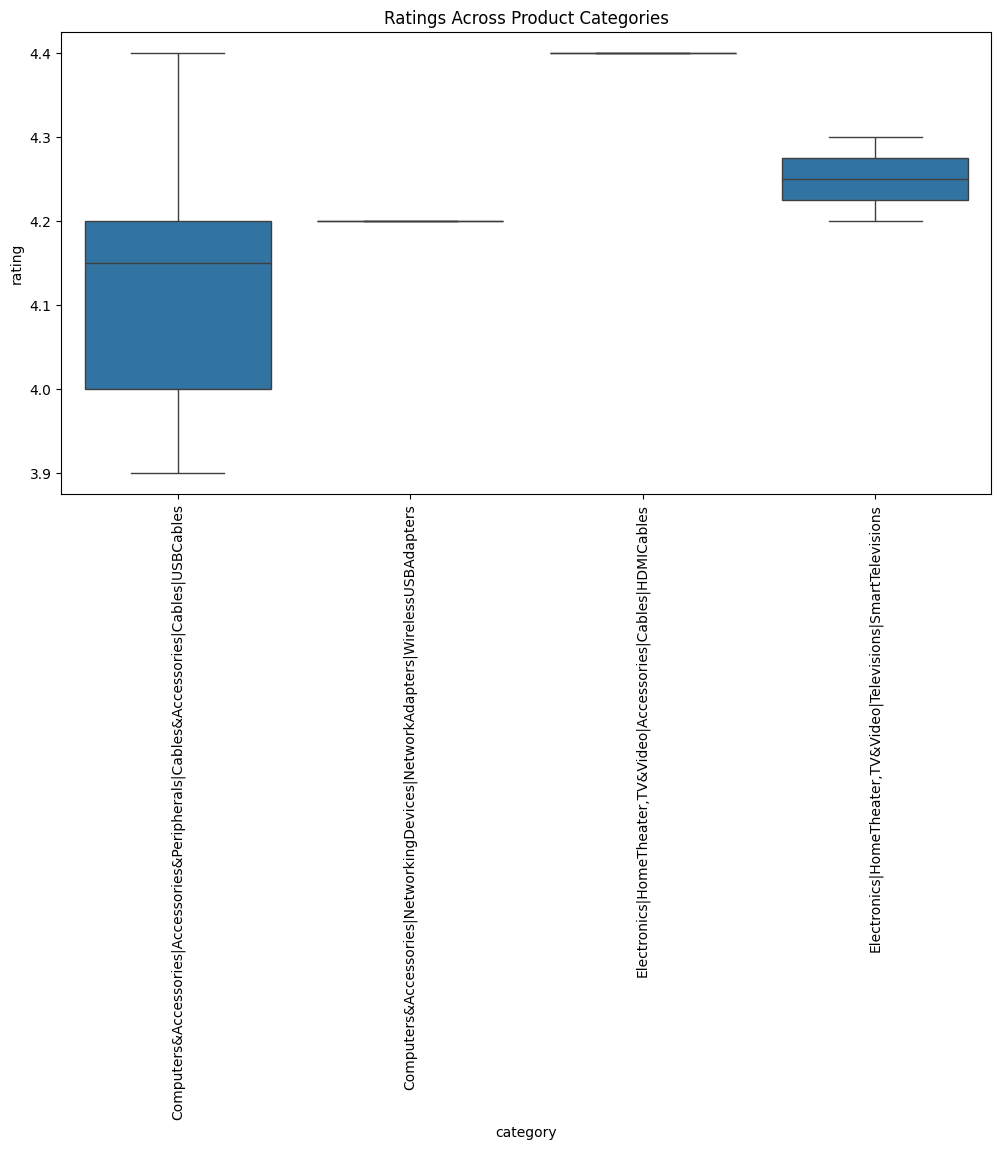

In [30]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df["category"].head(20),
    y=df["rating"].head(20)
)

plt.xticks(rotation=90)

plt.title("Ratings Across Product Categories")

plt.show()

# **Word Cloud Visualization**

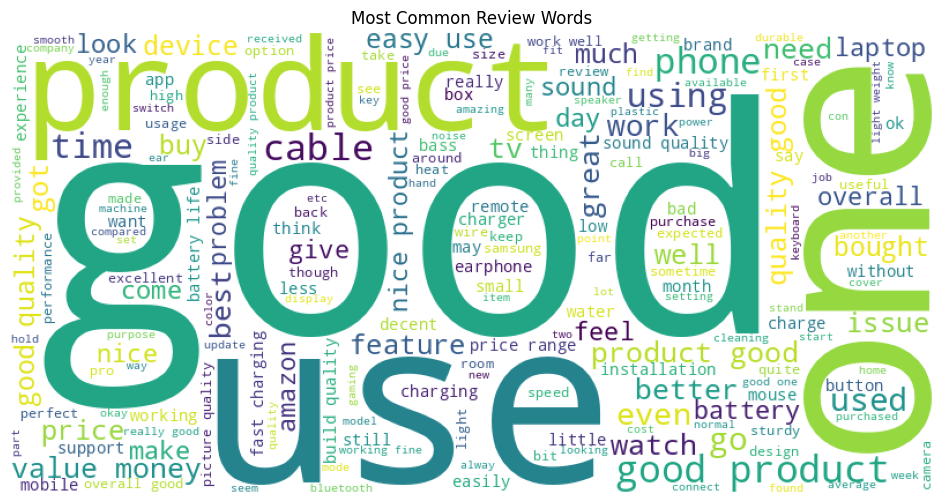

In [31]:
from wordcloud import WordCloud

text = " ".join(df["review_clean"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Review Words")

plt.show()

# **Saved Cleaned Data**

In [ ]:
# Save cleaned dataframe locally
df.to_csv(
    "amazon_cleaned.csv",
    index=False
)

print("amazon_cleaned.csv saved successfully.")

# **Sentiment Analysis with VADER**

In [ ]:
# =====================================
# Sentiment Analysis with VADER
# =====================================

from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Generate sentiment scores
df["sentiment_score"] = df["review_clean"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

# Preview results
display(
    df[
        [
            "review_clean",
            "sentiment_score"
        ]
    ].head()
)

# **Sentiment Analysis & Visualization**

---



In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["sentiment_score"],
    bins=20
)

plt.title("Customer Sentiment Distribution")

plt.xlabel("Sentiment Score")

plt.ylabel("Count")

plt.show()

## Key Insights

- Most customer reviews were positive based on VADER sentiment scores.
- Several product categories consistently received higher ratings.
- Discounted products tended to receive larger volumes of reviews.
- NLP preprocessing improved review consistency for downstream modeling tasks.

## **Business Value & Applications**

The preprocessing and sentiment analysis workflow developed in this notebook can help in a few ways. The first is to help the ecommerce platforms better understand customer satisfaction trends and identify common product issues. I think also generate actionable business insights from large scale review data.

These NLP techniques can support
- customer sentiment monitoring (keeps tabs on overall relationship the customers have with the products/ company at a macro level if most of the products have bad reviews)
- product quality analysis (great for updating and meeting specificity with teams like the product managers and marketing teams)
- recommendation systems (helping curate a better system to increase overall purchasing sizes for each customer --> increasing life time value and reducing marketing costs)
- automated review summarization (saves time and effort for team having to parse through hundreds of reviews)
- customer experience optimization (improves overall experience which leads to longer relationships with recurring business of customer)